In [2]:
# E-Commerce Sales Data Analytics
# Task 3: Dataset Loading and Initial Data Inspection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../Dataset/ecommerce_sales_dataset.csv")

# Display first 5 rows
df.head()

ModuleNotFoundError: No module named 'matplotlib'

In [4]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import sys
print(sys.executable)

C:\Users\Anjali\AppData\Local\Programs\Python\Python314\python.exe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load E-Commerce Sales Dataset

df = pd.read_csv(
    r"C:\Users\Anjali\Documents\ecommerce-sales-data-analytics\1. Dataset\ecommerce_sales_dataset.csv"
)

# Display first 5 rows
df.head()

,Order_ID,Order_Date,Region,Category,Customer_Segment,Payment_Method,Units_Sold,Unit_Price,Discount,Sales,Profit
0,ORD1001,2025-01-01,East,Books,Corporate,Credit Card,1,33.90,0.00,33.90,6.12
1,ORD1002,2025-01-02,Central,Sports,Corporate,Cash on Delivery,4,108.16,0.00,432.65,86.13
2,ORD1003,2025-01-03,Central,Home & Kitchen,Corporate,Credit Card,6,153.96,0.00,923.77,86.29
3,ORD1004,2025-01-05,North,Sports,Small Business,Credit Card,4,118.54,0.05,474.17,100.76
4,ORD1005,2025-01-06,North,Sports,Corporate,Debit Card,6,109.64,0.00,657.85,80.24


In [3]:
# Basic Information about the Dataset

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (252, 11)

Column Names:
['Order_ID', 'Order_Date', 'Region', 'Category', 'Customer_Segment', 'Payment_Method', 'Units_Sold', 'Unit_Price', 'Discount', 'Sales', 'Profit']

Data Types:
Order_ID                str
Order_Date              str
Region                  str
Category                str
Customer_Segment        str
Payment_Method          str
Units_Sold            int64
Unit_Price          float64
Discount            float64
Sales               float64
Profit              float64
dtype: object

Missing Values:
Order_ID            0
Order_Date          0
Region              0
Category            0
Customer_Segment    3
Payment_Method      0
Units_Sold          0
Unit_Price          0
Discount            0
Sales               0
Profit              0
dtype: int64

Duplicate Rows: 2


In [4]:
# Data Cleaning

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing Customer_Segment values
df["Customer_Segment"] = df["Customer_Segment"].fillna("Consumer")

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Check cleaning result
print("Dataset Shape after Cleaning:", df.shape)
print("\nMissing Values after Cleaning:")
print(df.isnull().sum())
print("\nDuplicate Rows after Cleaning:", df.duplicated().sum())

Dataset Shape after Cleaning: (250, 11)

Missing Values after Cleaning:
Order_ID            0
Order_Date          0
Region              0
Category            0
Customer_Segment    0
Payment_Method      0
Units_Sold          0
Unit_Price          0
Discount            0
Sales               0
Profit              0
dtype: int64

Duplicate Rows after Cleaning: 0


In [5]:
# Task 4: Exploratory Data Analysis

# Descriptive Statistics
df.describe()

,Order_Date,Units_Sold,Unit_Price,Discount,Sales,Profit
count,250,250.000000,250.000000,250.000000,250.000000,250.000000
mean,2025-07-01 12:05:45.600000,4.096000,173.802600,0.080000,723.241560,105.546240
min,2025-01-01 00:00:00,1.000000,28.370000,0.000000,28.370000,2.130000
25%,2025-04-01 12:00:00,2.000000,64.702500,0.050000,171.080000,21.722500
50%,2025-07-01 12:00:00,4.000000,106.305000,0.100000,460.035000,54.235000
75%,2025-09-30 12:00:00,6.000000,176.322500,0.100000,858.715000,123.870000
max,2025-12-31 00:00:00,7.000000,559.920000,0.200000,3587.910000,809.450000
std,NaN,2.001702,162.228583,0.061278,805.823512,141.276075


In [6]:
# Category-wise Sales Analysis

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print("Total Sales by Category:")
print(category_sales)

Total Sales by Category:
Category
Electronics       105899.11
Home & Kitchen     35035.41
Sports             17277.82
Clothing           14214.20
Books               8383.85
Name: Sales, dtype: float64


In [7]:
# Region-wise Sales Analysis

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print("Total Sales by Region:")
print(region_sales)

Total Sales by Region:
Region
North      45944.26
Central    36213.03
East       34912.54
South      33422.42
West       30318.14
Name: Sales, dtype: float64


In [8]:
# Customer Segment-wise Sales Analysis

segment_sales = df.groupby("Customer_Segment")["Sales"].sum().sort_values(ascending=False)

print("Total Sales by Customer Segment:")
print(segment_sales)

Total Sales by Customer Segment:
Customer_Segment
Small Business    61624.54
Corporate         61446.83
Consumer          57739.02
Name: Sales, dtype: float64


In [9]:
# Profit Analysis

profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

print("Total Profit by Category:")
print(profit_by_category)

Total Profit by Category:
Category
Electronics       15755.56
Home & Kitchen     4884.98
Sports             2399.64
Clothing           2142.79
Books              1203.59
Name: Profit, dtype: float64


In [10]:
# Correlation Analysis

numeric_columns = [
    "Units_Sold",
    "Unit_Price",
    "Discount",
    "Sales",
    "Profit"
]

correlation_matrix = df[numeric_columns].corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
            Units_Sold  Unit_Price  Discount     Sales    Profit
Units_Sold    1.000000    0.035077  0.086109  0.456441  0.363657
Unit_Price    0.035077    1.000000  0.032183  0.810155  0.699274
Discount      0.086109    0.032183  1.000000  0.051805 -0.080353
Sales         0.456441    0.810155  0.051805  1.000000  0.858328
Profit        0.363657    0.699274 -0.080353  0.858328  1.000000


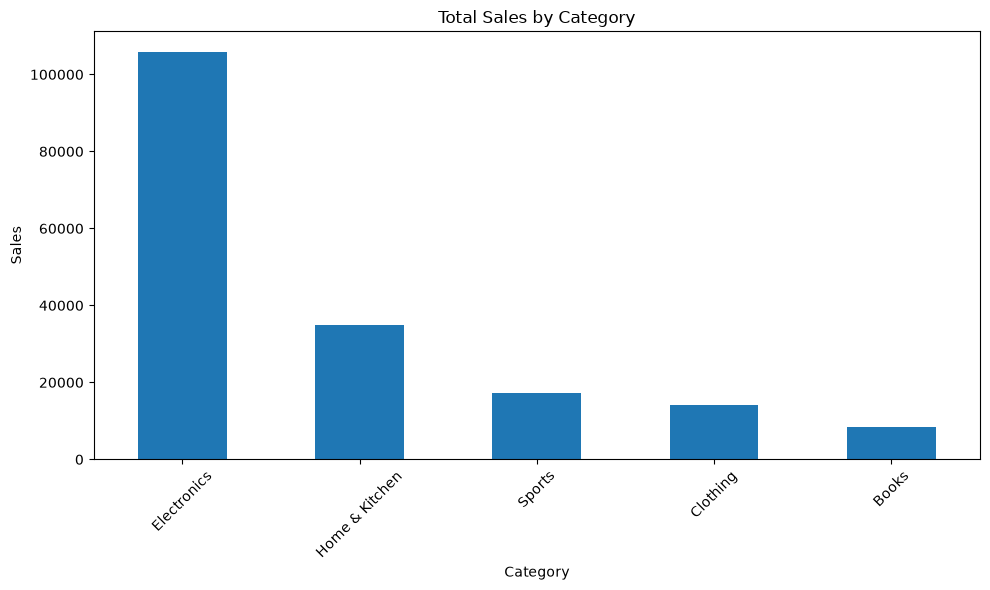

In [11]:
# Visualization 1: Sales by Category

plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

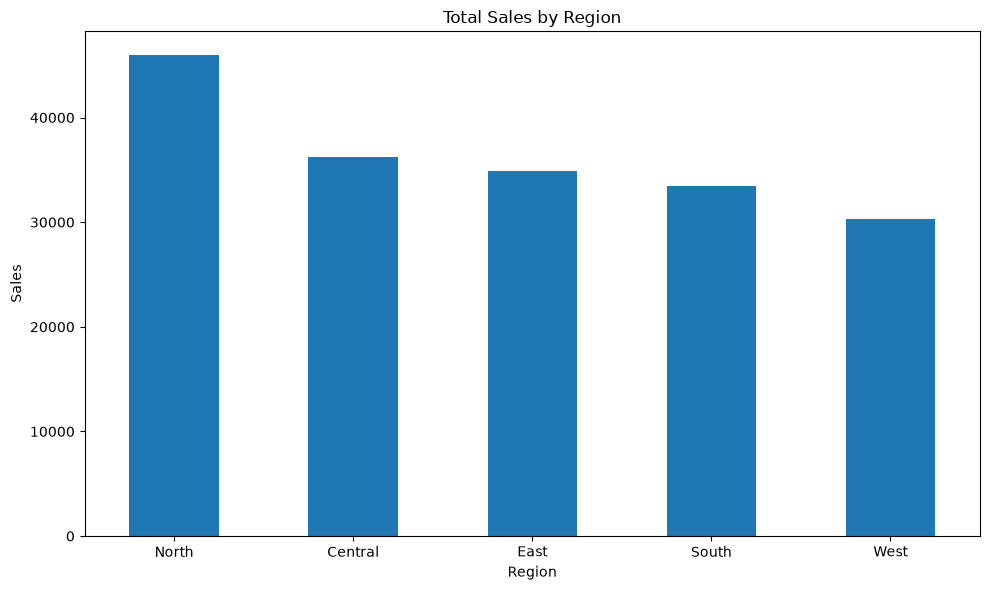

In [12]:
# Visualization 2: Sales by Region

plt.figure(figsize=(10, 6))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

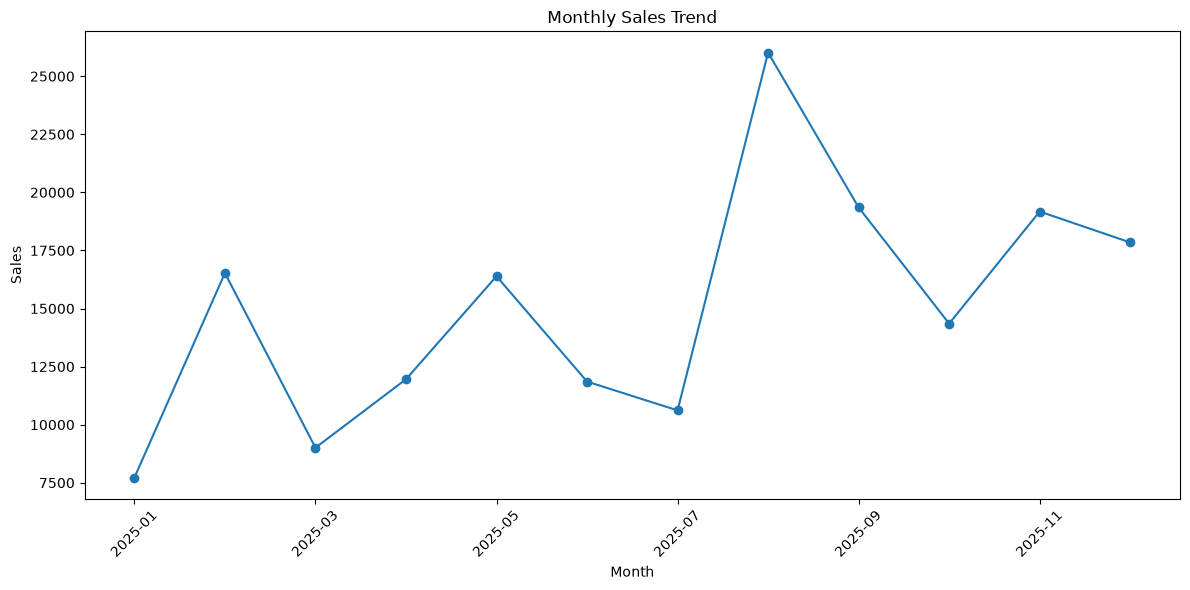

In [13]:
# Visualization 3: Monthly Sales Trend

df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12, 6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

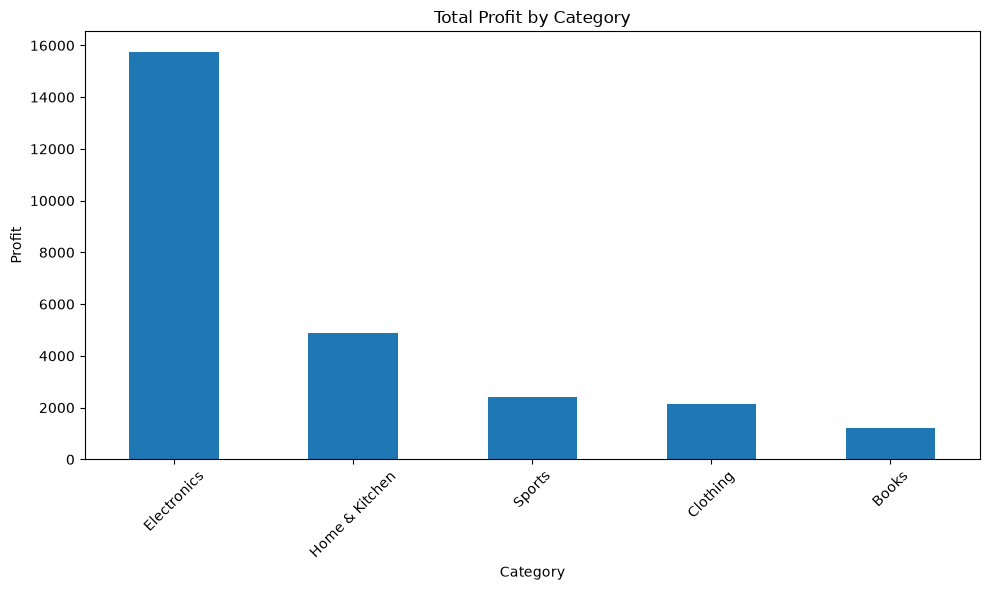

In [14]:
# Visualization 4: Profit by Category

plt.figure(figsize=(10, 6))

profit_by_category.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

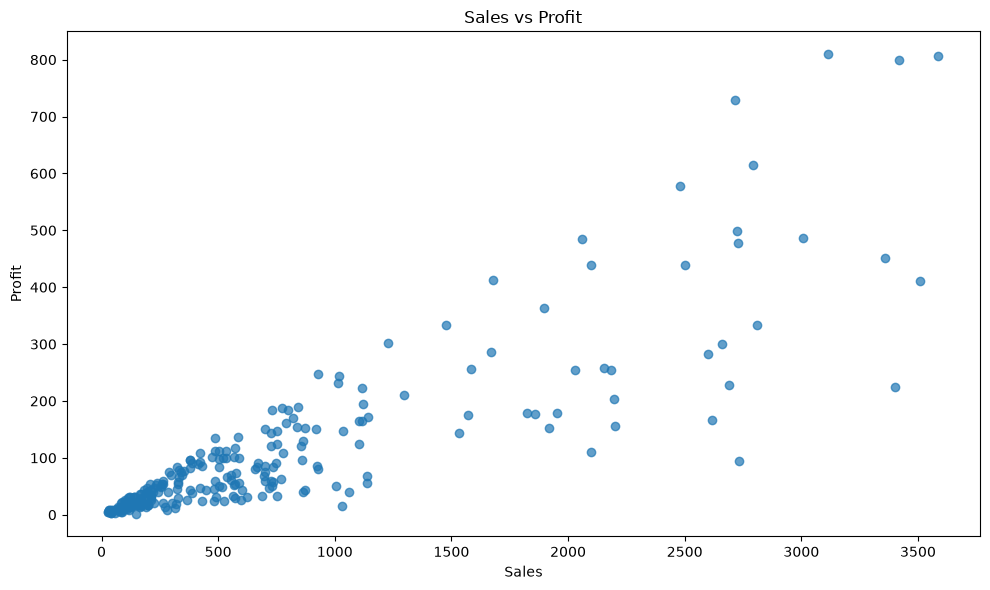

In [15]:
# Visualization 5: Sales vs Profit

plt.figure(figsize=(10, 6))

plt.scatter(df["Sales"], df["Profit"], alpha=0.7)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [16]:
# Business Insights

print("BUSINESS INSIGHTS")
print("-" * 50)

print("1. Category-wise sales analysis helps identify the best-performing product categories.")
print("2. Region-wise sales analysis shows which regions generate higher sales.")
print("3. Customer segment analysis helps understand the purchasing contribution of different customer groups.")
print("4. Profit analysis identifies categories contributing more to overall profitability.")
print("5. The monthly sales trend helps identify changes in sales performance over time.")

print("\nRECOMMENDATIONS")
print("-" * 50)

print("1. Focus marketing and inventory planning on high-performing categories.")
print("2. Improve promotions and customer strategies in lower-performing regions or segments.")

BUSINESS INSIGHTS
--------------------------------------------------
1. Category-wise sales analysis helps identify the best-performing product categories.
2. Region-wise sales analysis shows which regions generate higher sales.
3. Customer segment analysis helps understand the purchasing contribution of different customer groups.
4. Profit analysis identifies categories contributing more to overall profitability.
5. The monthly sales trend helps identify changes in sales performance over time.

RECOMMENDATIONS
--------------------------------------------------
1. Focus marketing and inventory planning on high-performing categories.
2. Improve promotions and customer strategies in lower-performing regions or segments.
